In [2]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
)

from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import LabelEncoder

from src.config import DADOS_LIMPOS
from src.models import RANDOM_STATE


In [4]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,concavity_se,concavity_worst,diagnosis,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst,perimeter_mean,perimeter_se,perimeter_worst,radius_mean,radius_se,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,0.05373,0.7119,M,0.07871,0.006193,0.11890,122.80,8.589,184.60,17.99,1.0950,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,0.01860,0.2416,M,0.05667,0.003532,0.08902,132.90,3.398,158.80,20.57,0.5435,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,0.03832,0.4504,M,0.05999,0.004571,0.08758,130.00,4.585,152.50,19.69,0.7456,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,0.05661,0.6869,M,0.09744,0.009208,0.17300,77.58,3.445,98.87,11.42,0.4956,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,0.05688,0.4000,M,0.05883,0.005115,0.07678,135.10,5.438,152.20,20.29,0.7572,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [5]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [6]:
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

# uso do LabelEncoder do scikit learn

# os 10 primeiros registros sao de tumores malignos

In [7]:
le = LabelEncoder()

y = le.fit_transform(y)

y[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [8]:
le.classes_

array(['B', 'M'], dtype=object)

In [9]:
y[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

#uso do numpy.bincount do numpy

In [11]:
np.bincount(y_train)

array([267, 159])

In [12]:
np.bincount(y_train) / len(y_train)

array([0.62676056, 0.37323944])

In [13]:
np.bincount(y_test)

array([90, 53])

In [14]:
np.bincount(y_test) / len(y_test)

array([0.62937063, 0.37062937])

In [15]:
clf = Perceptron()

clf.fit(X_train, y_train)

Perceptron()

In [16]:
y_pred = clf.predict(X_test)

In [17]:
clf.score(X_test, y_test)

0.9020979020979021

# Problemas da Acurácia 
Acurácia nao é o unico métrica para classificacao 
No nosso caso temos uma acuracia de aprox 0.902 das predicoes feitas na base de teste foram corretas

No entando, a acuracia nao é uma metrica perfeita para avaliar a qualidade de um modelo. por exmeplo, se tivermos um dataset com 90% dos exemplos da classe de 1 a 10% de exemplos de classe 0, um modelo que sempre prediz a classe 1 terá uma acuracia de 90% mas nao é um modelo util 

Alem disso, a acuracia trata todos os erros da mesma forma, mas em muitos casos, erros de um tipo podem ser mais graves.. por exemplo, um problema de deteccao de doencas, um falso negativo

é importante encontrar uma forma de penalizar os erros em formas "maiores"

In [19]:
print(y_test[:20])
print(y_pred[:20])

[1 0 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1]
[1 0 1 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0]


In [21]:
accuracy_score(y_test, y_pred)

0.9020979020979021

Matriz de Confusão e Matriz de Confusão Display =--> Scikit Learn

In [24]:
np.bincount(y_test)

array([90, 53])

In [23]:
confusion_matrix(y_test, y_pred)

array([[89,  1],
       [13, 40]])

In [26]:
le.classes_

array(['B', 'M'], dtype=object)

In [28]:
le.inverse_transform([0,1])

array(['B', 'M'], dtype=object)

In [29]:
y_test == y_pred

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True, False,  True,  True,  True,
        True, False,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True, False,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,

In [30]:
np.bincount(y_test == y_pred)

array([ 14, 129])

In [34]:
y_test[y_test == 1] == y_pred[y_test==1]

array([ True,  True,  True,  True, False, False,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False, False,  True,  True, False,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
       False,  True,  True,  True, False, False, False,  True])

In [36]:
np.bincount(y_test[y_test == 1] == y_pred [y_test== 1])

array([13, 40])

In [37]:
y_test[y_test == 0] == y_pred[y_test==0]

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True])

In [38]:
np.bincount(y_test[y_test == 0] == y_pred [y_test== 0])

array([ 1, 89])

89/(89+1+13+40)

In [39]:
confusion_matrix(y_test, y_pred, normalize="all")

array([[0.62237762, 0.00699301],
       [0.09090909, 0.27972028]])

89/(89+1)
*geralmente o true é o mais usado

In [ ]:
confusion_matrix(y_test, y_pred, normalize="true")

array([[0.98888889, 0.01111111],
       [0.24528302, 0.75471698]])

89/(89+13)

In [41]:
confusion_matrix(y_test, y_pred, normalize="pred")

array([[0.87254902, 0.02439024],
       [0.12745098, 0.97560976]])

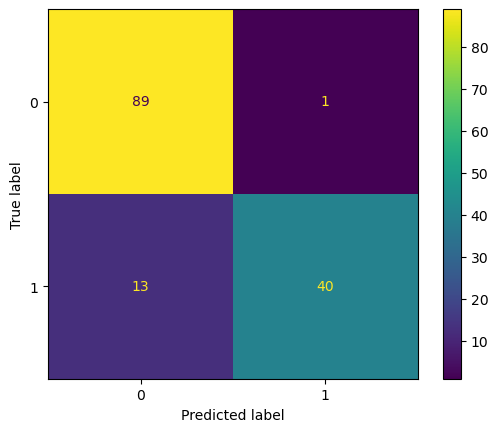

In [42]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay (confusion_matrix=cm)

disp.plot()

- Facilitando a leitura inserindo o display labels

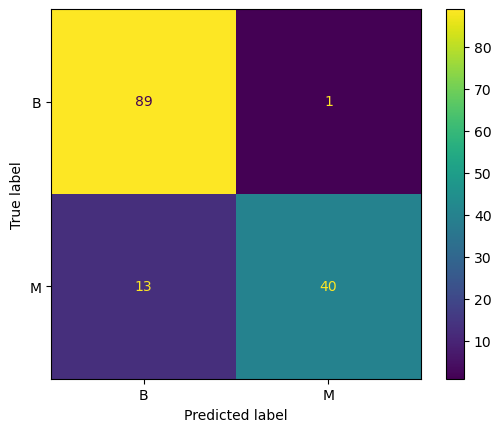

In [43]:
disp = ConfusionMatrixDisplay (confusion_matrix=cm, display_labels=le.classes_)

disp.plot()

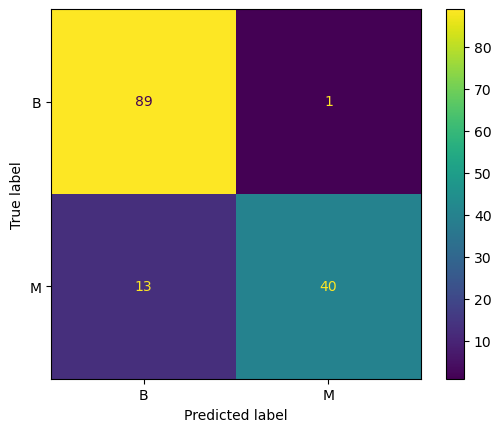

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_)

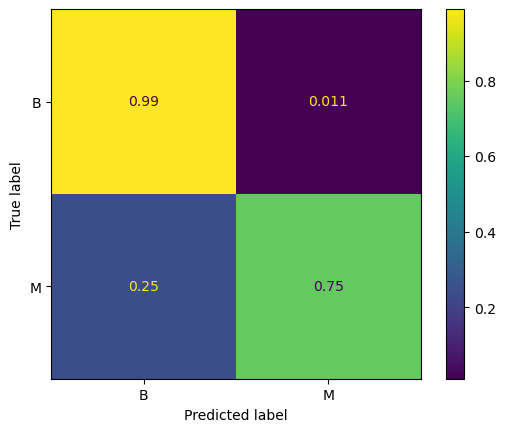

In [47]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, normalize="true")

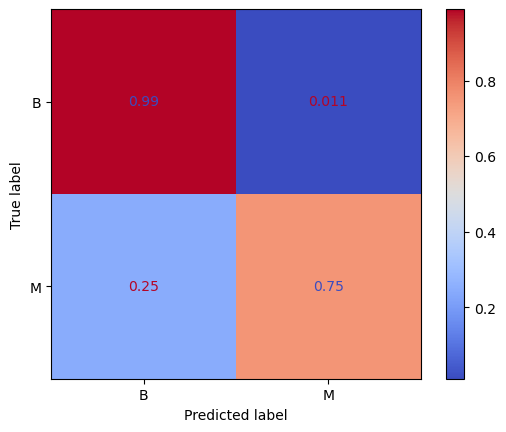

In [48]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, normalize="true", cmap="coolwarm")

- Voce precisa prestar atencao sobre qual das metricas usar 

In [49]:
recall_score(y_test, y_pred)

np.float64(0.7547169811320755)

In [50]:
precision_score(y_test, y_pred)

np.float64(0.975609756097561)

In [ ]:
f1_score(y_test, y_pred)

np.float64(0.851063829787234)

In [52]:
fbeta_score(y_test, y_pred, beta=0.5)

np.float64(0.9216589861751152)

In [53]:
fbeta_score(y_test, y_pred, beta=2)

np.float64(0.7905138339920948)

- Curva Roc: primeira se calcula a area sob a curva
- Funcao do skicit learn que vai fazendo a curva : roc_curve - taxas de falsos positivos, verdadeiros positivos e limeares

In [57]:
roc_auc = roc_auc_score(y_test, y_pred)
roc_auc

np.float64(0.8718029350104822)

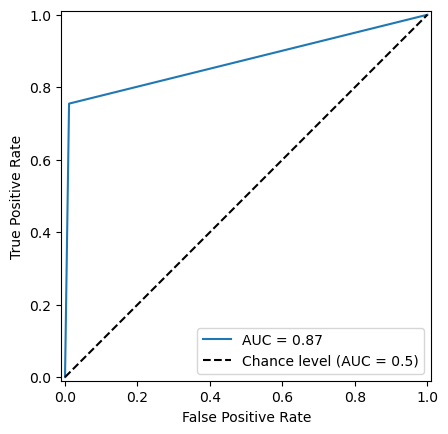

In [59]:
fpr, tpr, limiares = roc_curve(y_test, y_pred)

disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
disp.plot(plot_chance_level=True)

- Curva Precion Recall é bem parecida


In [61]:
average_precision = average_precision_score(y_test, y_pred) #area sob a curva de precisao
average_precision

np.float64(0.8272183407940426)

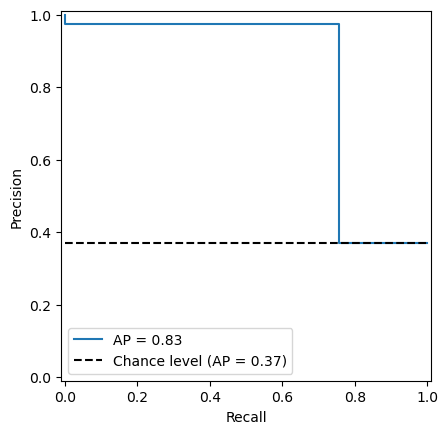

In [63]:
precision, recall, limiares = precision_recall_curve(y_test, y_pred)

disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=average_precision, prevalence_pos_label=y_test.mean())

disp.plot   (plot_chance_level=True)

classification report oferece as 3 medias globais: acuracia, macro avg e weighted avg - com as médias voce consegue visualizar o desbalanceamento entre os modelos 

In [66]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

           B       0.87      0.99      0.93        90
           M       0.98      0.75      0.85        53

    accuracy                           0.90       143
   macro avg       0.92      0.87      0.89       143
weighted avg       0.91      0.90      0.90       143

